A)

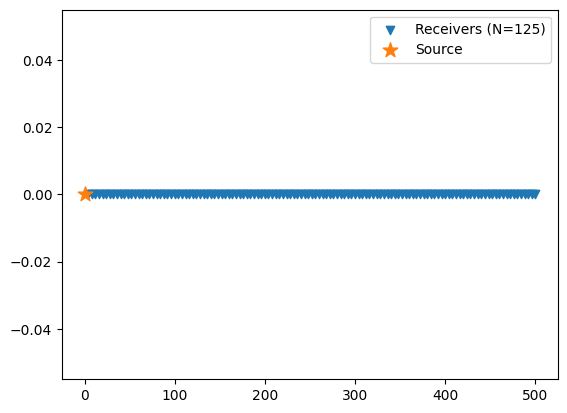

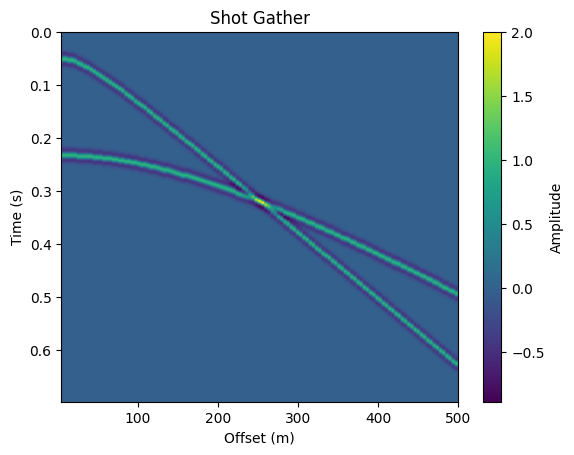

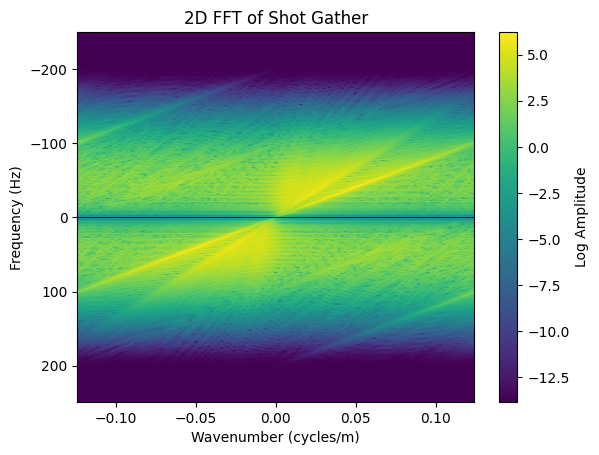

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
s_x = 0
r_space = 4
n_r = len(np.arange(4, 501, r_space))

# Geometry
r = np.arange(4, 501, r_space)

dt = 0.002
n_t = 350
t = np.arange(n_t) * dt

fc = 40.0
n_w = 127
t_w = (np.arange(n_w) - n_w // 2) * dt
wavelet = (1 - 2 * (np.pi * fc * t_w) ** 2) * np.exp(-(np.pi * fc * t_w) ** 2)

# Layered Velocity Model
v = np.array([800.0, 1200.0, 2000.0])
h = np.array([20.0, 110.0])

# Reflection Times
t0_1 = 2 * h[0] / v[0]
t0_2 = 2 * (h[0] / v[0] + h[1] / v[1])
t0 = [t0_1, t0_2]

# RMS Velocity Calculation
vrms = [
    v[0],
    np.sqrt((v[0] ** 2 * h[0] + v[1] ** 2 * h[1]) / (h[0] + h[1]))
]

# Initialize Synthetic Gather
g = np.zeros((n_t, n_r))

# Gathering Data
for i, x in enumerate(r):
    for k in range(2):  # Two reflectors
        t_effective = np.sqrt(t0[k] ** 2 + (x / vrms[k]) ** 2)
        it0 = int(t_effective / dt)

        for j in range(n_w):
            it = it0 + j - n_w // 2
            if 0 <= it < n_t:
                g[it, i] += wavelet[j]

# Plot Geometry
plt.figure()
plt.scatter(r, np.zeros_like(r), marker='v', label=f"Receivers (N={n_r})")
plt.scatter(s_x, 0, marker='*', s=120, label="Source")
plt.legend()
plt.show()

# Plot Shot Gather
plt.figure()
plt.imshow(g, aspect='auto', extent=[r[0], r[-1], t[-1], t[0]])
plt.xlabel("Offset (m)")
plt.ylabel("Time (s)")
plt.colorbar(label="Amplitude")
plt.title("Shot Gather")
plt.show()

# 2D FFT (f-k Transform)
fk = np.fft.fft2(g)
fk = np.fft.fftshift(fk)

# Frequency and Wavenumber Axes
freq = np.fft.fftshift(np.fft.fftfreq(n_t, dt))
dx = r_space
k = np.fft.fftshift(np.fft.fftfreq(n_r, dx))

fk_amp = np.log(np.abs(fk) + 1e-6)

# Plot f-k Spectrum
plt.figure()
plt.imshow(fk_amp, aspect='auto', extent=[k[0], k[-1], freq[-1], freq[0]])
plt.xlabel("Wavenumber (cycles/m)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Log Amplitude")
plt.title("2D FFT of Shot Gather")
plt.show()


B)

In [2]:
v = np.array([400.0, 700.0, 1200.0])
h = np.array([20.0, 110.0])

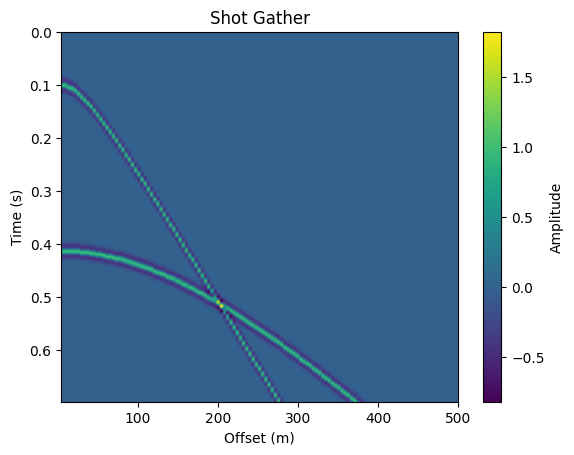

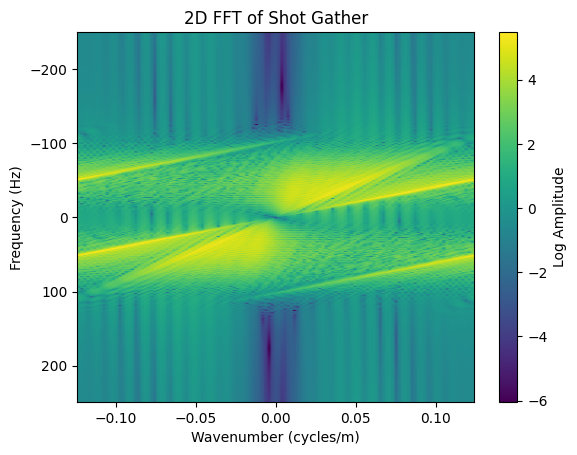

In [4]:

t0_1 = 2 * h[0] / v[0]
t0_2 = 2 * (h[0] / v[0] + h[1] / v[1])
t0 = [t0_1, t0_2]

# RMS Velocity Calculation
vrms = [
    v[0],
    np.sqrt((v[0] ** 2 * h[0] + v[1] ** 2 * h[1]) / (h[0] + h[1]))
]

# Initialize Synthetic Gather
g = np.zeros((n_t, n_r))

# Gathering Data
for i, x in enumerate(r):
    for k in range(2):  # Two reflectors
        t_effective = np.sqrt(t0[k] ** 2 + (x / vrms[k]) ** 2)
        it0 = int(t_effective / dt)

        for j in range(n_w):
            it = it0 + j - n_w // 2
            if 0 <= it < n_t:
                g[it, i] += wavelet[j]


# Plot Shot Gather
plt.figure()
plt.imshow(g, aspect='auto', extent=[r[0], r[-1], t[-1], t[0]])
plt.xlabel("Offset (m)")
plt.ylabel("Time (s)")
plt.colorbar(label="Amplitude")
plt.title("Shot Gather")
plt.show()

# 2D FFT (f-k Transform)
fk = np.fft.fft2(g)
fk = np.fft.fftshift(fk)

# Frequency and Wavenumber Axes
freq = np.fft.fftshift(np.fft.fftfreq(n_t, dt))
dx = r_space
k = np.fft.fftshift(np.fft.fftfreq(n_r, dx))

fk_amp = np.log(np.abs(fk) + 1e-6)

# Plot f-k Spectrum
plt.figure()
plt.imshow(fk_amp, aspect='auto', extent=[k[0], k[-1], freq[-1], freq[0]])
plt.xlabel("Wavenumber (cycles/m)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Log Amplitude")
plt.title("2D FFT of Shot Gather")
plt.show()